# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [129]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from statistics import mean
import pandas as pd
from typing import Iterable, List, Tuple

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import DirectedGraph, UndirectedGraph
from NEMtropy import matrix_generator as mg
from NEMtropy.network_functions import build_adjacency_from_edgelist


In [2]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_GREEN = 'palegreen'
COLOR_RED = 'lightcoral'
COLOR_YELLOW = 'gold'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [4]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
### OUTPUT_PATH_ERGMS = os.path.join(OUTPUT_PATH, "ERGMs")


# Recreate the subdirectories
### os.makedirs(OUTPUT_PATH_ERGMS)

In [5]:
# Define the directory containing the .gml files
directory = 'datasets'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files: 100%|██████████| 4/4 [00:00<00:00, 24.43it/s]

Finished loading graph1.2
Finished loading graph_madrid
Finished loading graph_jazz_collab
Finished loading graph1.1


# 1. Compartmental Models on Networks

## 1.1 
Write a function to simulate the SI dynamic on a generic network and provide a visualisation.
The function should take in input:
- a network, e.g. if you are using networkx a generic nx.Graph,
- the infection rate β,
- an infected seed node.

You may also want to add other parameters, e.g. the maximum number of steps for the simulation (some
bad things may happen if you don’t). As an output, the function should return the list of nodes infected
in the simulation. Additionally, run the SI function for an adequate number of steps, with β = 0.5 on
the following two graphs (the datasets are provided), with infected seed node “10”:
- graph1.1.gml
- graph1.2.gml

and provide a visualisation of the final state of the epidemic, where all the infected nodes at the end of
the run are red, or blue if they are not infected.

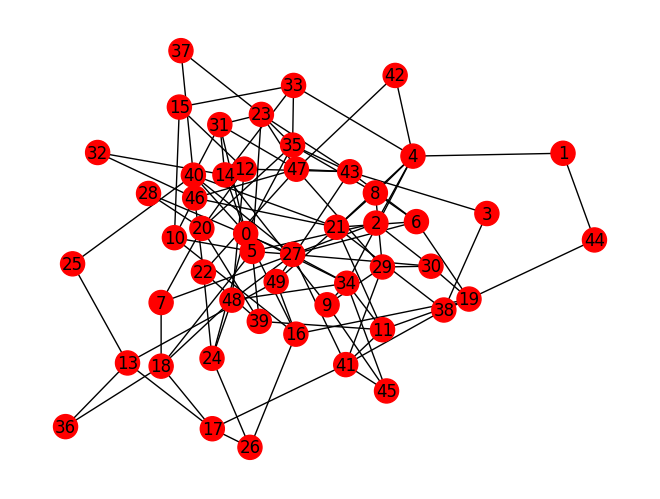

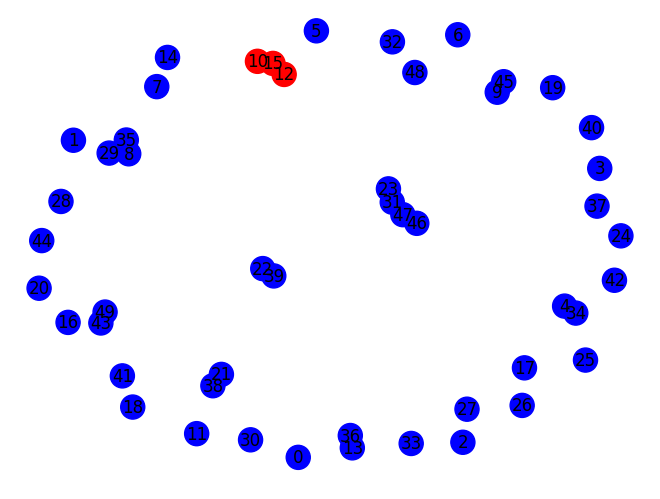

In [89]:
def si_simulation(graph, beta, seed_node, max_steps=100):
    # Set of infected nodes with the seed node
    infected_nodes = set()
    infected_nodes.add(seed_node)

    nodes = set(graph.nodes) # Set of all nodes in the graph
    steps = 0

    while steps < max_steps:
        cp_infected_nodes = infected_nodes.copy()
        susceptible_nodes = nodes - cp_infected_nodes # Identify susceptible nodes by subtracting infected nodes from all nodes

        for node in susceptible_nodes:
            neighbors = set(graph.neighbors(node)) # Get neighbors of current node
            infected_neighbors = neighbors & cp_infected_nodes # Get infected neighbors of current node

            num_infected_neighbors = len(infected_neighbors)

            if num_infected_neighbors > 0:
                prob_healthy = (1-beta)**num_infected_neighbors
                prob_infected = 1 - prob_healthy
                if random() < prob_infected:
                    infected_nodes.add(node) # Node gets infected

        steps += 1

    return list(infected_nodes)

def visualize_epidemic(graph, infected_nodes):
    pos = nx.spring_layout(graph)
    nx.draw(graph, pos, node_color=['red' if node in infected_nodes else 'blue' for node in graph.nodes], with_labels=True)
    plt.show()


# Example usage with two provided graphs
graph1_1 = graphs["graph1.1"]
graph1_2 = graphs["graph1.2"]

beta = 0.5
seed_node = "10"

infected_nodes1_1 = si_simulation(graph1_1, beta, seed_node)
visualize_epidemic(graph1_1, infected_nodes1_1)

infected_nodes1_2 = si_simulation(graph1_2, beta, seed_node)
visualize_epidemic(graph1_2, infected_nodes1_2)

## 1.2 
To extend the function you wrote for point 1 in order to simulate the SIS model. You need to
introduce γ,i.e. the recovery rate, to the input parameters of the function.

Provide a plot of ρ^I and ρ^S as a function of the simulation time-step, on graph graph1.1.gml with
β = 0.2 and γ = 0.4 over 1000 steps (at least). Choose a random seed such that you don’t end up in
the trivial stationary states (ρ^I, ρ^S) = (0, 1)

Hint: in order to observe “smoother” result you can use a moving average. You can check out moving
average functions on pandas| python module, or implement it yourself.

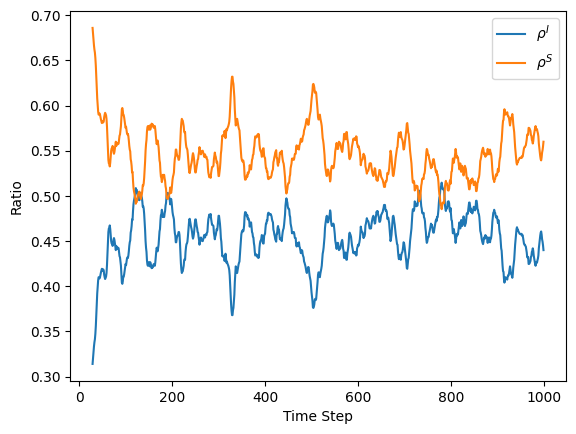

In [132]:
def sis_simulation(graph, beta, gamma, seed_node, max_steps=100):
    infected_nodes = {seed_node}
    nodes = set(graph.nodes)
    
    infected_ratios = []
    susceptible_ratios = []

    for step in range(max_steps):
        newly_infected = set()
        newly_recovered = set()

        for infected_node in infected_nodes:
            for neighbor in graph.neighbors(infected_node):
                if neighbor not in infected_nodes and np.random.uniform(0, 1) < beta:
                    newly_infected.add(neighbor)
            if np.random.uniform(0, 1) < gamma:
                newly_recovered.add(infected_node)

        infected_nodes.update(newly_infected)
        infected_nodes.difference_update(newly_recovered)

        infected_ratio = len(infected_nodes) / len(nodes)
        susceptible_ratio = 1 - infected_ratio

        infected_ratios.append(infected_ratio)
        susceptible_ratios.append(susceptible_ratio)

    return infected_ratios, susceptible_ratios

def moving_average(lst, window_size):
    return pd.Series(lst).rolling(window=window_size).mean()

# Example
graph1_1 = graphs["graph1.1"]

beta = 0.2
gamma = 0.4
seed_node = np.random.choice(list(graph1_1.nodes))
max_steps = 1000

# Run the SIS simulation
infected_ratios, susceptible_ratios = sis_simulation(graph1_1, beta, gamma, seed_node, max_steps)

# Plot infected and susceptible ratios with moving average
window_size = 30
infected_ratios_smooth = moving_average(infected_ratios, window_size)
susceptible_ratios_smooth = moving_average(susceptible_ratios, window_size)

plt.plot(infected_ratios_smooth, label=r'$\rho^I$')
plt.plot(susceptible_ratios_smooth, label=r'$\rho^S$')
plt.xlabel('Time Step')
plt.ylabel('Ratio')
plt.legend()
plt.show()

## 1.3
Observe how the infected share of the population stationary state is affected by the network topology, in the SIS model. You have to plot the stationary state share of infected nodes ρ^I (t = ∞) as a function of β/γ, on two different kind of network structures:
- For the Erdos-Renyi N = 500 and p = 6/N
- For the Barabasi-Albert N = 500 and m = 3

You can use networkx native functions to create the networks. You need to average ρ^I on multiple SIS
runs, a sample size of 100 SIS simulations per β/γ combination will work. For the x-axis of the plot β/γ
chose a logarithmic scale with at least 10 values in the interval [0, 1].

On the y-axis you need to plot:
- ρ^IER (t = ∞), the share of infected nodes in the stationary state for the Erdos-Renyi network,
averaged over at least 100 simulations as a function of β/γ
- ER critical epidemic threshold RC.
- ρ^IBA(t = ∞), the share of infected nodes in the stationary state for the Barabasi-Albert network,
averaged over at least 100 simulations as a function of β/γ
- BA critical epidemic threshold RC.

Hint: It may take a while to run the simulations, take this into account.


Average Simulation Progress: 100%|██████████| 100/100 [01:06<00:00,  1.50it/s]


Execution time: 1307.59 seconds


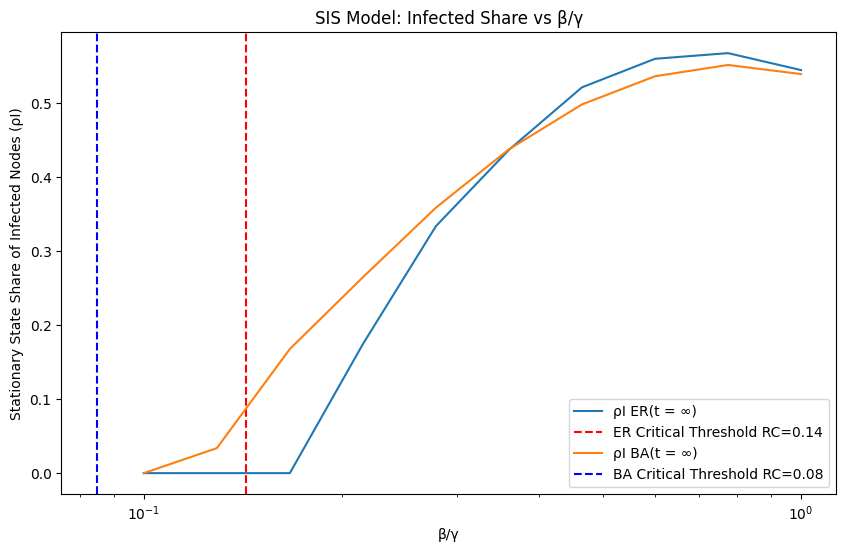

In [137]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm  # Import tqdm

def sis_simulation(graph, beta, gamma, seed, max_steps=1000):
    random.seed(seed)
    p = random.uniform(0, 1)

    nodes = set(graph.nodes)
    infected_nodes = set(np.random.choice(list(nodes), size=int(p * len(nodes)), replace=False))
    susceptible_nodes = nodes - infected_nodes

    for step in tqdm(range(max_steps), desc="Simulation Progress"):
        cp_infected_nodes = infected_nodes.copy()
        cp_susceptible_nodes = susceptible_nodes.copy()

        for node in cp_susceptible_nodes:
            neighbors = set(graph.neighbors(node))
            infected_neighbors = neighbors & cp_infected_nodes

            v = len(infected_neighbors)
            p_infection = 1 - (1 - beta) ** v
            if random.uniform(0, 1) < p_infection:
                infected_nodes.add(node)
                susceptible_nodes.remove(node)

        for node in cp_infected_nodes:
            if random.uniform(0, 1) < gamma:
                infected_nodes.remove(node)
                susceptible_nodes.add(node)

    return len(infected_nodes) / len(nodes)

def average_sis_simulation(graph, beta, gamma, sample_size=100, seed=None):
    results = []
    for _ in tqdm(range(sample_size), desc="Average Simulation Progress"):
        result = sis_simulation(graph, beta, gamma, seed, max_steps=1000)
        results.append(result)
    return np.mean(results)

# Parameters
beta_gamma_values = np.logspace(-1, 0, 10)
gamma_values = np.logspace(-1, -0.1, 10)
beta_values = beta_gamma_values * gamma_values
sample_size = 100

# Create Erdos-Renyi network
N_er = 500
p_er = 6 / N_er
er_graph = nx.erdos_renyi_graph(N_er, p_er)

# Create Barabasi-Albert network
N_ba = 500
m_ba = 3
ba_graph = nx.barabasi_albert_graph(N_ba, m_ba)

# Initialize timer
start_time = time.time()

# Perform simulations and calculate averages
rho_i_er = [average_sis_simulation(er_graph, beta, gamma, sample_size) for beta, gamma in zip(beta_values, gamma_values)]
rho_i_ba = [average_sis_simulation(ba_graph, beta, gamma, sample_size) for beta, gamma in zip(beta_values, gamma_values)]

def calculate_critical_er_threshold(graph):
    avg_degree = sum(dict(graph.degree()).values()) / len(graph)
    return 1 / (avg_degree + 1)

def calculate_critical_ba_threshold(graph):
    avg_degree = sum(dict(graph.degree()).values()) / len(graph)
    avg_square_degree = sum([degree ** 2 for degree in dict(graph.degree()).values()]) / len(graph)
    return avg_degree / avg_square_degree

# Calculate critical thresholds
rc_er = calculate_critical_er_threshold(er_graph)
rc_ba = calculate_critical_ba_threshold(ba_graph)

# Print execution time
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.2f} seconds")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(beta_gamma_values, rho_i_er, label=f'ρI ER(t = ∞)')
plt.axvline(x=rc_er, color='r', linestyle='--', label=f'ER Critical Threshold RC={rc_er:.2f}')
plt.plot(beta_gamma_values, rho_i_ba, label=f'ρI BA(t = ∞)')
plt.axvline(x=rc_ba, color='b', linestyle='--', label=f'BA Critical Threshold RC={rc_ba:.2f}')

plt.xscale('log')
plt.xlabel('β/γ')
plt.ylabel('Stationary State Share of Infected Nodes (ρI)')
plt.title('SIS Model: Infected Share vs β/γ')
plt.legend()
plt.show()

## 1.4
Observe the effect of different immunisation strategies. Modify your SIS function to introduce
the immunised state, a state where the node cannot get infected nor spread any more. Then implement
two different immunised strategies:

- Random strategy: immunised a fraction g ∈ [0, 1] of the population, where the nodes immunised
are chosen randomly.
- Target Strategy: consider a fraction g of nodes randomly. For each node randomly chosen, immunised their largest degree neighbour.

To compare the strategies, run the epidemics simulations on a Barabasi-Albert network with N = 1000
and m = 3 with β = 0.3 and γ = 0.6, immunised with g ranging ∈ [0, 1]. Produce a plot where:

- On the x-axis there is g the share of immunised nodes.
- On the y-axis there is ρ^I (t = ∞), the stationary state of share of infected nodes, as a function of
g, for the two immunisation strategies.

Hint: Keep in mind you want to compute the average value of ρ^I (t = ∞) over multiple run, to avoid small sample bias.

Hint: It may take a while to run the simulations, take this into account.

Look at task_1.4